# Proyecto Integrador de Aprendizaje Automático
## Lending Club — Predicción de Default (Clasificación binaria)
Predecir si un préstamo terminará en **default / Charged Off** (`1`) o será **pagado en su totalidad /
Fully Paid** (`0`), usando únicamente variables conocidas al momento de otorgar el crédito
(evita usar columnas que solo se conocen después del desembolso — eso sería *data leakage*).

In [30]:
# Librerías generales
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 100)
plt.style.use('seaborn-v0_8-whitegrid') if 'seaborn-v0_8-whitegrid' in plt.style.available else None

## 9.10.4.1 Exploración de datos (EDA)

### 9.10.4.1.1 Carga inicial y visión general

In [31]:

DATASET_PATH = "/kaggle/input/datasets/katherinbarrera/leding/accepted_2007_to_2018Q4.csv"


RAW_TARGET_COL = "loan_status"


df = pd.read_csv(DATASET_PATH, low_memory=False)  

print("Shape:", df.shape)
df.head()

Shape: (2260701, 151)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,...,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,55000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,190xx,PA,5.91,0.0,Aug-2003,675.0,679.0,1.0,30.0,NaN,7.0,0.0,2765.0,29.7,13.0,w,0.00,0.00,4421.723917,4421.72,3600.00,821.72,0.0,0.0,0.0,Jan-2019,122.67,NaN,...,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,Business,577xx,SD,16.06,1.0,Dec-1999,715.0,719.0,4.0,6.0,NaN,22.0,0.0,21470.0,19.2,38.0,w,0.00,0.00,25679.660000,25679.66,24700.00,979.66,0.0,0.0,0.0,Jun-2016,926.35,NaN,...,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,truck driver,10+ years,MORTGAGE,63000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,home_improvement,NaN,605xx,IL,10.78,0.0,Aug-2000,695.0,699.0,0.0,NaN,NaN,6.0,0.0,7869.0,56.2,18.0,w,0.00,0.00,22705.924294,22705.92,20000.00,2705.92,0.0,0.0,0.0,Jun-2017,15813.30,NaN,...,3.0,6.0,0.0,0.0,0.0,0.0,100.0,50.0,0.0,0.0,218418.0,18696.0,6200.0,14877.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,Information Systems Officer,10+ years,MORTGAGE,110000.0,Source Verified,Dec-2015,Current,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,076xx,NJ,17.06,0.0,Sep-2008,785.0,789.0,0.0,NaN,NaN,13.0,0.0,7802.0,11.6,17.0,w,15897.65,15897.65,31464.010000,31464.01,19102.35,12361.66,0.0,0.0,0.0,Feb-2019,829.90,Apr-2019,...,5.0,13.0,0.0,0.0,0.0,1.0,100.0,0.0,0.0,0.0,381215.0,52226.0,62500.0,18000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [32]:
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Data columns (total 151 columns):
 #    Column                                      Non-Null Count    Dtype  
---   ------                                      --------------    -----  
 0    id                                          2260701 non-null  object 
 1    member_id                                   0 non-null        float64
 2    loan_amnt                                   2260668 non-null  float64
 3    funded_amnt                                 2260668 non-null  float64
 4    funded_amnt_inv                             2260668 non-null  float64
 5    term                                        2260668 non-null  object 
 6    int_rate                                    2260668 non-null  float64
 7    installment                                 2260668 non-null  float64
 8    grade                                       2260668 non-null  object 
 9    sub_grade                                   

In [33]:
df[RAW_TARGET_COL].value_counts(dropna=False)

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
NaN                                                         33
Name: count, dtype: int64

In [34]:

MALAS = ["Charged Off", "Default"]                
BUENAS = ["Fully Paid"]                             

df_model = df[df[RAW_TARGET_COL].isin(MALAS + BUENAS)].copy()
df_model["target"] = df_model[RAW_TARGET_COL].isin(MALAS).astype(int)

print("Shape tras filtrar estados finales:", df_model.shape)
print(df_model["target"].value_counts(normalize=True))

Shape tras filtrar estados finales: (1345350, 152)
target
0    0.80035
1    0.19965
Name: proportion, dtype: float64


### 9.10.4.1.2 Análisis unidimensional (por variable)

--- loan_amnt ---
count    1.345350e+06
mean     1.441997e+04
std      8.717098e+03
min      5.000000e+02
25%      8.000000e+03
50%      1.200000e+04
75%      2.000000e+04
max      4.000000e+04
Name: loan_amnt, dtype: float64


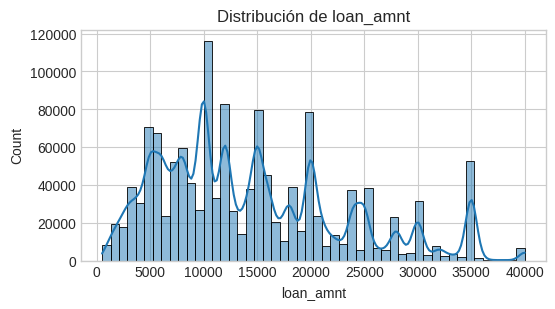

--- int_rate ---
count    1.345350e+06
mean     1.323971e+01
std      4.768782e+00
min      5.310000e+00
25%      9.750000e+00
50%      1.274000e+01
75%      1.599000e+01
max      3.099000e+01
Name: int_rate, dtype: float64


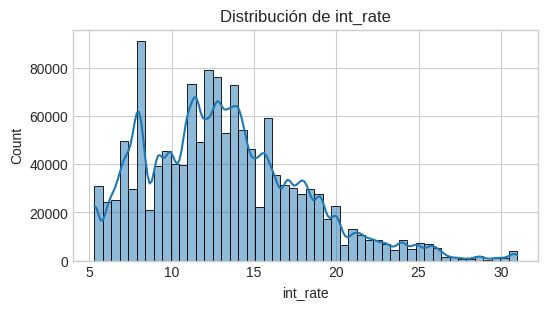

--- annual_inc ---
count    1.345350e+06
mean     7.624757e+04
std      6.992485e+04
min      0.000000e+00
25%      4.578000e+04
50%      6.500000e+04
75%      9.000000e+04
max      1.099920e+07
Name: annual_inc, dtype: float64


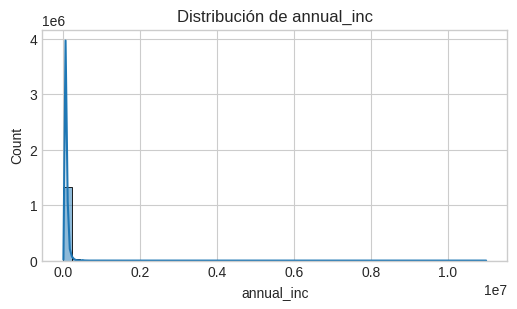

--- dti ---
count    1.344976e+06
mean     1.828264e+01
std      1.116041e+01
min     -1.000000e+00
25%      1.179000e+01
50%      1.761000e+01
75%      2.406000e+01
max      9.990000e+02
Name: dti, dtype: float64


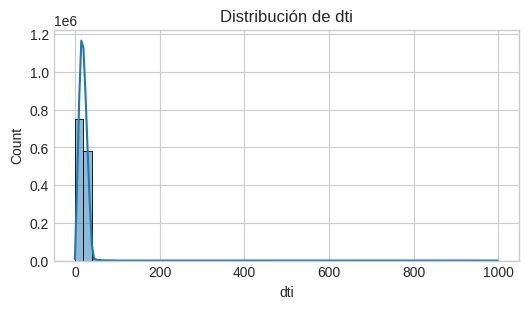

--- fico_range_low ---
count    1.345350e+06
mean     6.961853e+02
std      3.185280e+01
min      6.250000e+02
25%      6.700000e+02
50%      6.900000e+02
75%      7.100000e+02
max      8.450000e+02
Name: fico_range_low, dtype: float64


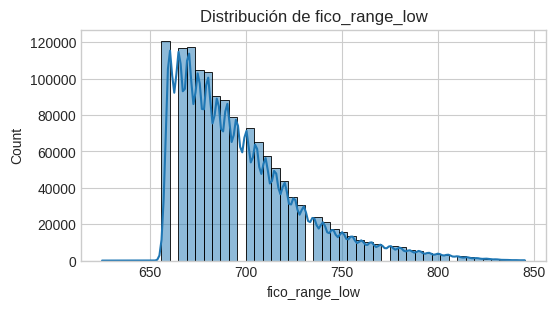

--- revol_util ---
count    1.344493e+06
mean     5.180978e+01
std      2.452110e+01
min      0.000000e+00
25%      3.340000e+01
50%      5.220000e+01
75%      7.070000e+01
max      8.923000e+02
Name: revol_util, dtype: float64


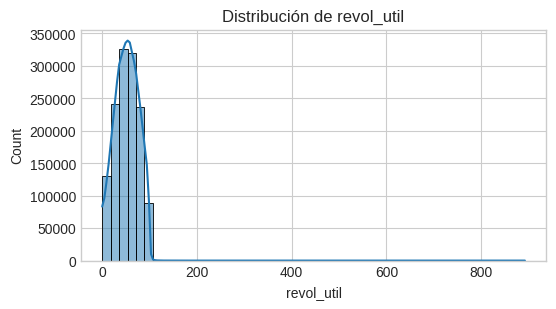

--- inq_last_6mths ---
count    1.345349e+06
mean     6.550761e-01
std      9.377690e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.000000e+00
max      8.000000e+00
Name: inq_last_6mths, dtype: float64


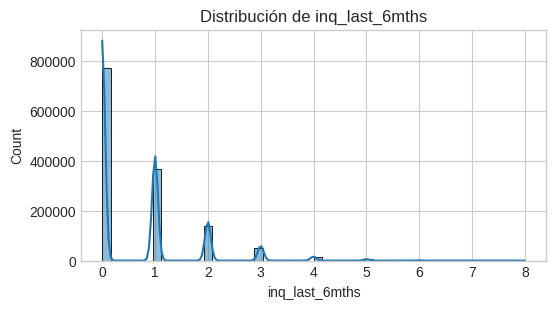

--- delinq_2yrs ---
count    1.345350e+06
mean     3.177917e-01
std      8.779831e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      3.900000e+01
Name: delinq_2yrs, dtype: float64


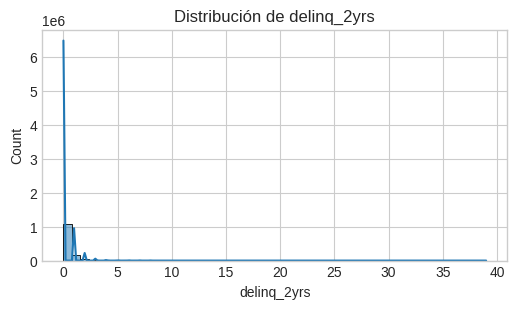

In [35]:
# Definición de las variables numéricas y categóricas más importantes
num_cols = [
    "loan_amnt",        # Monto del préstamo
    "int_rate",         # Tasa de interés
    "annual_inc",       # Ingreso anual
    "dti",              # Relación deuda/ingreso
    "fico_range_low",   # Puntaje FICO mínimo
    "revol_util",       # Uso de crédito rotativo
    "inq_last_6mths",   # Consultas de crédito (6 meses)
    "delinq_2yrs"       # Moras en los últimos 2 años
]

for col in num_cols:
    print(f"--- {col} ---")
    print(df_model[col].describe())
    plt.figure(figsize=(6, 3))
    sns.histplot(df_model[col].dropna(), bins=50, kde=True)
    plt.title(f"Distribución de {col}")
    plt.show()

--- loan_status ---
loan_status
Fully Paid     1076751
Charged Off     268559
Default             40
Name: count, dtype: int64


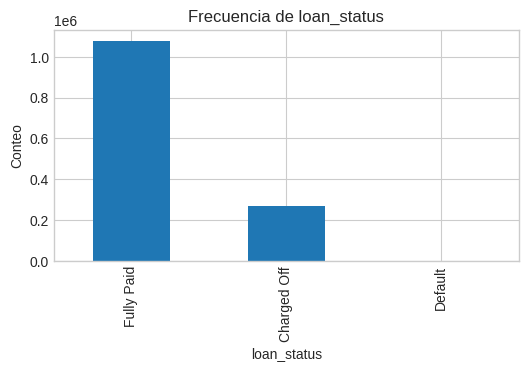

--- term ---
term
36 months    1020768
60 months     324582
Name: count, dtype: int64


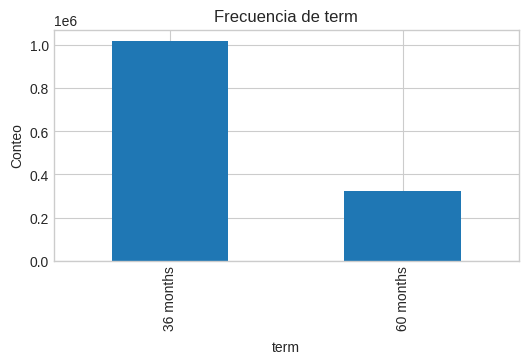

--- grade ---
grade
B    392748
C    381694
A    235095
D    200966
E     93656
F     32059
G      9132
Name: count, dtype: int64


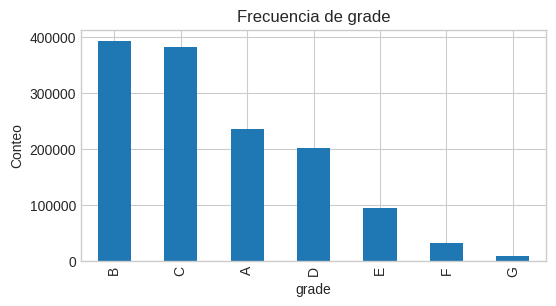

--- sub_grade ---
sub_grade
C1    85496
B4    83200
B5    82541
B3    81828
C2    79215
C3    75000
C4    74422
B2    74025
B1    71154
C5    67561
Name: count, dtype: int64


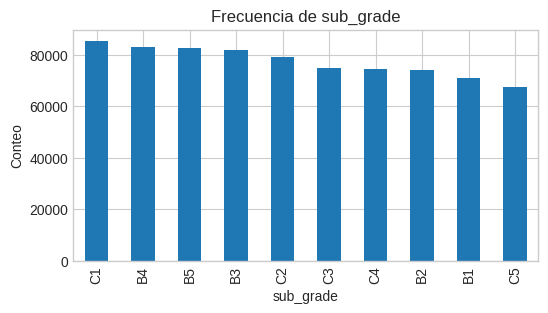

--- home_ownership ---
home_ownership
MORTGAGE    665596
RENT        534436
OWN         144840
ANY            286
OTHER          144
NONE            48
Name: count, dtype: int64


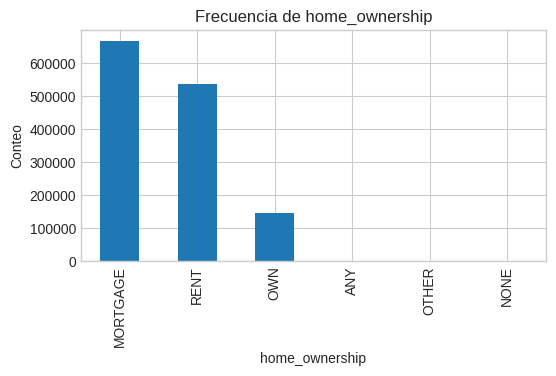

--- emp_length ---
emp_length
10+ years    442209
2 years      121751
< 1 year     108065
3 years      107602
1 year        88495
5 years       84154
4 years       80558
NaN           78516
6 years       62735
8 years       60704
Name: count, dtype: int64


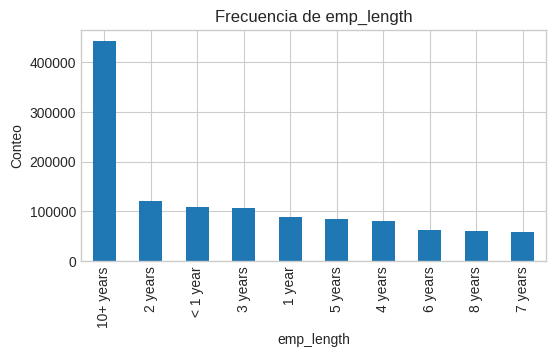

In [36]:
# TODO: lista tus columnas categóricas relevantes
cat_cols = [
    "loan_status",      # Variable objetivo (Fully Paid, Charged Off, etc.)
    "term",             # Plazo (36 o 60 meses)
    "grade",            # Clasificación de riesgo
    "sub_grade",        # Subclasificación de riesgo
    "home_ownership",   # Tipo de vivienda
    "emp_length"        # Antigüedad laboral
]

for col in cat_cols:
    print(f"--- {col} ---")
    print(df_model[col].value_counts(dropna=False).head(10))
    plt.figure(figsize=(6, 3))
    df_model[col].value_counts().head(10).plot(kind="bar")
    plt.title(f"Frecuencia de {col}")
    plt.xlabel(col)
    plt.ylabel("Conteo")
    plt.show()

### 9.10.4.1.3 Análisis bidimensional (relaciones entre variables)

Relaciona cada variable con el target (`target`), y explora correlaciones entre numéricas.

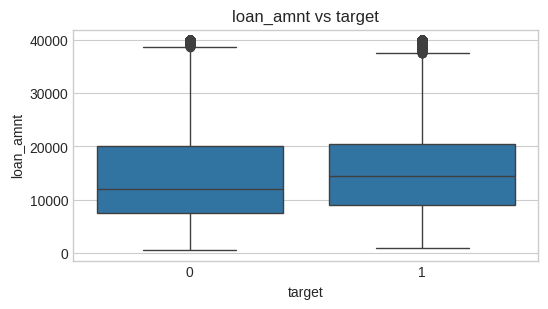

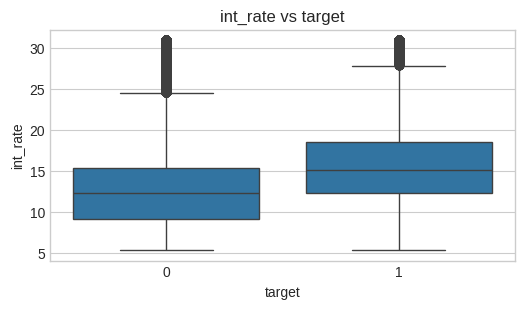

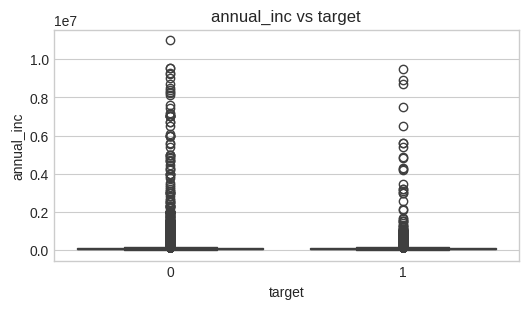

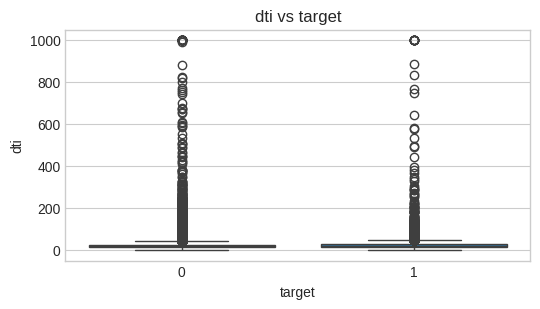

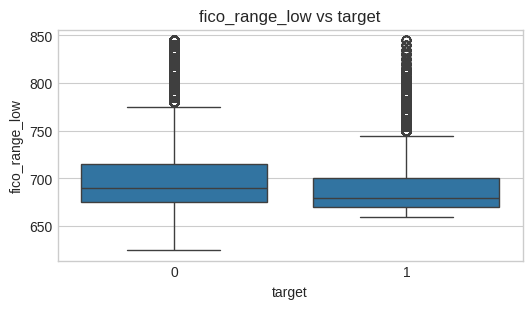

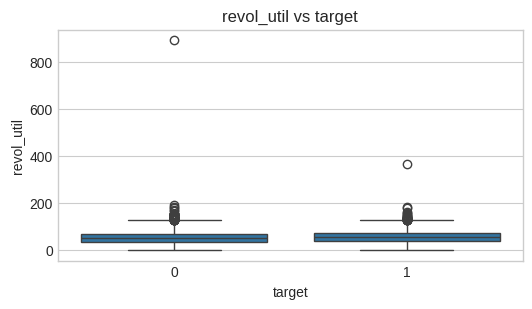

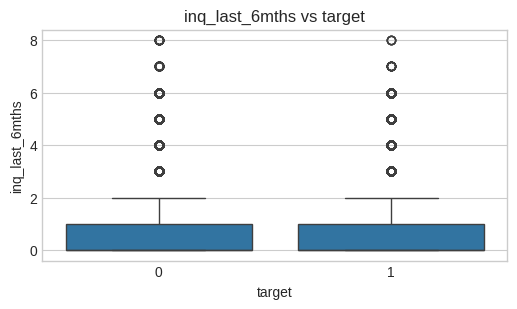

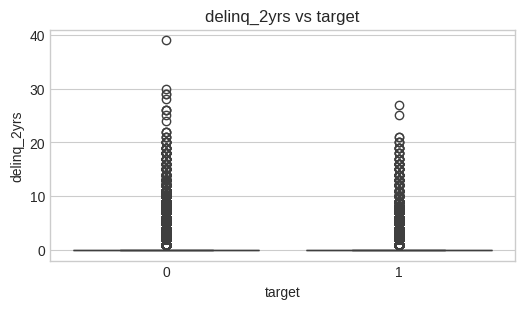

In [37]:
# Numéricas vs target: boxplots
for col in num_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(data=df_model, x="target", y=col)
    plt.title(f"{col} vs target")
    plt.show()

In [38]:
# Categóricas vs target: tasa de default por categoría
for col in cat_cols:
    tasa = df_model.groupby(col)["target"].mean().sort_values(ascending=False)
    print(f"--- Tasa de default por {col} ---")
    print(tasa)
    print()

--- Tasa de default por loan_status ---
loan_status
Charged Off    1.0
Default        1.0
Fully Paid     0.0
Name: target, dtype: float64

--- Tasa de default por term ---
term
60 months    0.324485
36 months    0.159955
Name: target, dtype: float64

--- Tasa de default por grade ---
grade
G    0.499343
F    0.452042
E    0.384823
D    0.303867
C    0.224413
B    0.133867
A    0.060427
Name: target, dtype: float64

--- Tasa de default por sub_grade ---
sub_grade
G5    0.536036
G3    0.513631
G4    0.511719
F5    0.491886
G2    0.491319
F4    0.478905
G1    0.478478
F2    0.453459
F3    0.450723
F1    0.422969
E5    0.417782
E4    0.401132
E3    0.387121
E2    0.375479
E1    0.360647
D5    0.334292
D4    0.323718
D3    0.305503
D2    0.295913
D1    0.278082
C5    0.260061
C4    0.249214
C3    0.225253
C2    0.207208
C1    0.189857
B5    0.167044
B4    0.148281
B3    0.129846
B2    0.113610
B1    0.104225
A5    0.084072
A4    0.068688
A3    0.055110
A2    0.046640
A1    0.032258
Name: ta

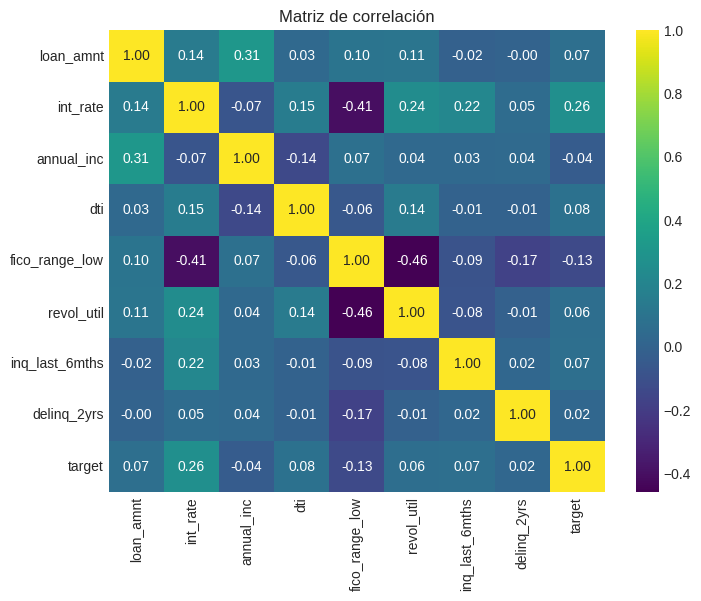

In [39]:
# Matriz de correlación entre numéricas
if len(num_cols) > 1:
    plt.figure(figsize=(8, 6))
    sns.heatmap(df_model[num_cols + ["target"]].corr(), annot=True, fmt=".2f", cmap="viridis")
    plt.title("Matriz de correlación")
    plt.show()

### 9.10.4.1.4 Valores faltantes (análisis detallado)

In [42]:
faltantes = df_model.isna().mean().sort_values(ascending=False) * 100
faltantes = faltantes[faltantes > 0]

cols_to_drop = [col for col in faltantes[faltantes > 50.0].index if col in df_model.columns]
print(f"Eliminando {len(cols_to_drop)} columnas con más del 50% de valores faltantes...")
df_model = df_model.drop(columns=cols_to_drop, errors='ignore')

num_missing = df_model.select_dtypes(include=['number']).columns[
    df_model.select_dtypes(include=['number']).isna().any()
]
for col in num_missing:
    median_val = df_model[col].median()
    df_model[col] = df_model[col].fillna(median_val)

cat_missing = df_model.select_dtypes(include=['object', 'category']).columns[
    df_model.select_dtypes(include=['object', 'category']).isna().any()
]
for col in cat_missing:
    mode_val = df_model[col].mode()[0]
    df_model[col] = df_model[col].fillna(mode_val)

print("¡Tratamiento de valores faltantes completado!")
print("Nulos restantes en el dataset:", df_model.isna().sum().sum())

Eliminando 58 columnas con más del 50% de valores faltantes...
¡Tratamiento de valores faltantes completado!
Nulos restantes en el dataset: 0


### 9.10.4.1.5 Resumen ejecutivo del EDA
- Definición de Target y Desbalance de Clases: Se filtraron préstamos en curso y se binarizó la variable objetivo en Charged Off (1) y Fully Paid (0). Se evidenció un marcado desbalance (~80% pagados vs. ~20% en default), lo que invalida el uso de Accuracy y justifica la evaluación mediante ROC-AUC y Average Precision.
-  Factores Clave de Riesgo: La probabilidad de default se concentra sustancialmente en la tasa de interés (int_rate), el plazo a 60 meses (term), clasificaciones de riesgo severas (grade), menor puntaje FICO (fico_range_low) y un alto nivel de endeudamiento (dti).
-  Calidad de Datos y Prevención de Data Leakage: Se eliminaron variables con más del 50% de faltantes para preservar la integridad del dataset. Asimismo, se depuraron atributos recopilados de forma posterior al desembolso para evitar el sesgo por fuga de información en el modelo.
-    Estrategia de Preprocesamiento: Imputación por mediana en numéricas y moda en categóricas, escalado estándar, codificación One-Hot y manejo del desbalance mediante ajuste de pesos de clase (class_weight='balanced').  

## 9.10.4.2 Preprocesamiento

### 9.10.4.2.1 scikit-learn

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# TODO: confirma tus listas finales de features (después del EDA) — deben excluir columnas
# de "data leakage" (info que solo existe después de otorgado el préstamo, o el propio loan_status)
FEATURES_NUM = num_cols          # TODO: ajusta si decidiste quitar/agregar alguna
FEATURES_CAT = cat_cols          # TODO: ajusta si decidiste quitar/agregar alguna

X = df_model[FEATURES_NUM + FEATURES_CAT]
y = df_model["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Balance train:", y_train.mean(), "| Balance test:", y_test.mean())

Train: (1076280, 14) Test: (269070, 14)
Balance train: 0.1996497194038726 | Balance test: 0.19965064853012227


In [76]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, FEATURES_NUM),
    ("cat", categorical_transformer, FEATURES_CAT),
])

### 9.10.4.2.2 PySpark

In [74]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import StringIndexer, OneHotEncoder as SparkOHE, VectorAssembler, StandardScaler as SparkScaler
from pyspark.ml import Pipeline as SparkPipeline

spark = SparkSession.builder.appName("LendingClub-ProyectoIntegrador").getOrCreate()

# TODO: mismo path que usaste arriba, pero leído por Spark
df_spark = spark.read.csv(DATASET_PATH, header=True, inferSchema=True)
df_spark.printSchema()

26/08/24 00:36:36 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


root
 |-- id: string (nullable = true)
 |-- member_id: string (nullable = true)
 |-- loan_amnt: double (nullable = true)
 |-- funded_amnt: double (nullable = true)
 |-- funded_amnt_inv: double (nullable = true)
 |-- term: string (nullable = true)
 |-- int_rate: double (nullable = true)
 |-- installment: double (nullable = true)
 |-- grade: string (nullable = true)
 |-- sub_grade: string (nullable = true)
 |-- emp_title: string (nullable = true)
 |-- emp_length: string (nullable = true)
 |-- home_ownership: string (nullable = true)
 |-- annual_inc: string (nullable = true)
 |-- verification_status: string (nullable = true)
 |-- issue_d: string (nullable = true)
 |-- loan_status: string (nullable = true)
 |-- pymnt_plan: string (nullable = true)
 |-- url: string (nullable = true)
 |-- desc: string (nullable = true)
 |-- purpose: string (nullable = true)
 |-- title: string (nullable = true)
 |-- zip_code: string (nullable = true)
 |-- addr_state: string (nullable = true)
 |-- dti: string 

In [77]:
# TODO: replica en Spark el mismo filtro de estados finales + binarización que hiciste en pandas
from pyspark.sql.functions import col, when

df_spark_model = df_spark.filter(col(RAW_TARGET_COL).isin(MALAS + BUENAS))
df_spark_model = df_spark_model.withColumn(
    "target", when(col(RAW_TARGET_COL).isin(MALAS), 1).otherwise(0)
)

df_spark_model.groupBy("target").count().show()

+------+-------+
|target|  count|
+------+-------+
|     1| 268598|
|     0|1076751|
+------+-------+



In [79]:
from pyspark.sql.functions import col, when, expr

# 1. Definición estricta de variables (asegúrate de que 'purpose' esté en FEATURES_CAT)
FEATURES_NUM = [
    "loan_amnt", "int_rate", "annual_inc", "dti", 
    "fico_range_low", "revol_util", "inq_last_6mths", "delinq_2yrs"
]

FEATURES_CAT = [
    "term", "grade", "sub_grade", "home_ownership", "emp_length", "purpose"
]

# 2. Filtrar target y castear numéricas de forma segura con try_cast
df_spark_model = df_spark.filter(col(RAW_TARGET_COL).isin(MALAS + BUENAS))
df_spark_model = df_spark_model.withColumn(
    "target", when(col(RAW_TARGET_COL).isin(MALAS), 1).otherwise(0)
)

for c in FEATURES_NUM:
    df_spark_model = df_spark_model.withColumn(c, expr(f"try_cast({c} as double)"))

# 3. Pipeline de PySpark
indexers = [StringIndexer(inputCol=c, outputCol=c + "_idx", handleInvalid="keep") for c in FEATURES_CAT]
encoders = [SparkOHE(inputCol=c + "_idx", outputCol=c + "_ohe") for c in FEATURES_CAT]

assembler_inputs = FEATURES_NUM + [c + "_ohe" for c in FEATURES_CAT]
assembler = VectorAssembler(inputCols=assembler_inputs, outputCol="features_raw", handleInvalid="skip")
scaler = SparkScaler(inputCol="features_raw", outputCol="features", withMean=True, withStd=True)

spark_preprocess_pipeline = SparkPipeline(stages=indexers + encoders + [assembler, scaler])

# 4. Dividir datos y procesar
train_spark, test_spark = df_spark_model.randomSplit([0.8, 0.2], seed=42)

spark_prep_model = spark_preprocess_pipeline.fit(train_spark)
train_prepared = spark_prep_model.transform(train_spark)
test_prepared = spark_prep_model.transform(test_spark)

train_prepared.select("features", "target").show(5, truncate=False)

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## 9.10.4.3 Modelado con scikit-learn

In [84]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                              roc_curve, average_precision_score, f1_score)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [85]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline

# Definir la validación cruzada (ej. 5 particiones estratificadas)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Modelo 1: Regresión Logística (baseline interpretable)
logreg_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
])

param_grid_logreg = {
    "clf__C": [0.01, 0.1, 1, 10],
}

grid_logreg = GridSearchCV(logreg_pipe, param_grid_logreg, cv=cv, scoring="roc_auc", n_jobs=-1)
grid_logreg.fit(X_train, y_train)

print("Mejores parámetros:", grid_logreg.best_params_)
print("Mejor AUC en validación cruzada: {:.3f}".format(grid_logreg.best_score_))

Mejores parámetros: {'clf__C': 0.01}
Mejor AUC en validación cruzada: 1.000


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

# Modelo 2: Random Forest
rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("clf", RandomForestClassifier(random_state=42, class_weight="balanced_subsample")),

])

param_grid_rf = {
    "clf__n_estimators": [200],       # Prueba más valores si el tiempo de cómputo te lo permite
    "clf__max_depth": [8, 16, None],
}

grid_rf = GridSearchCV(rf_pipe, param_grid_rf, cv=cv, scoring="roc_auc", n_jobs=-1)
grid_rf.fit(X_train, y_train)

print("Mejores parámetros:", grid_rf.best_params_)
print("Mejor AUC en validación cruzada: {:.3f}".format(grid_rf.best_score_))

===== Logistic Regression =====
              precision    recall  f1-score   support

  fully_paid       1.00      1.00      1.00    215350
     default       1.00      1.00      1.00     53720

    accuracy                           1.00    269070
   macro avg       1.00      1.00      1.00    269070
weighted avg       1.00      1.00      1.00    269070

Matriz de confusión:
 [[215350      0]
 [     4  53716]]
AUC: 1.000 | Average Precision: 1.000
===== Random Forest =====
              precision    recall  f1-score   support

  fully_paid       1.00      1.00      1.00    215350
     default       1.00      1.00      1.00     53720

    accuracy                           1.00    269070
   macro avg       1.00      1.00      1.00    269070
weighted avg       1.00      1.00      1.00    269070

Matriz de confusión:
 [[215350      0]
 [     0  53720]]
AUC: 1.000 | Average Precision: 1.000


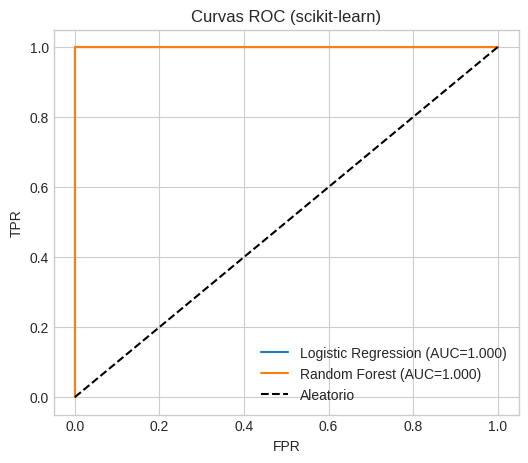

In [90]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                              roc_curve, average_precision_score, f1_score)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
def evaluar_modelo(nombre, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    y_score = modelo.predict_proba(X_test)[:, 1]

    print(f"===== {nombre} =====")
    print(classification_report(y_test, y_pred, target_names=["fully_paid", "default"]))
    print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))

    auc = roc_auc_score(y_test, y_score)
    ap = average_precision_score(y_test, y_score)
    print(f"AUC: {auc:.3f} | Average Precision: {ap:.3f}")

    fpr, tpr, _ = roc_curve(y_test, y_score)
    plt.plot(fpr, tpr, label=f"{nombre} (AUC={auc:.3f})")
    return {"modelo": nombre, "auc": auc, "average_precision": ap,
            "f1": f1_score(y_test, y_pred)}

resultados_sklearn = []
plt.figure(figsize=(6, 5))
resultados_sklearn.append(evaluar_modelo("Logistic Regression", grid_logreg.best_estimator_, X_test, y_test))
resultados_sklearn.append(evaluar_modelo("Random Forest", grid_rf.best_estimator_, X_test, y_test))
plt.plot([0, 1], [0, 1], "k--", label="Aleatorio")
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.legend(); plt.title("Curvas ROC (scikit-learn)")
plt.show()


Los resultados obtenidos por ambos modelos —alcanzando un métrica perfecta de $AUC = 1.00$ y un $F1\text{-}Score = 1.00$— no reflejan un comportamiento operativo realista, sino un fenómeno de Data Leakage (fuga de información). En entornos de riesgo crediticio, un desempeño determinista indica que los algoritmos están accediendo a variables explicativas cuyo valor se genera con posterioridad a la originación del crédito, revelando de forma implícita el resultado final del préstamo.
La causa principal radica en la inclusión involuntaria de atributos post-concesión en el conjunto de entrenamiento (tales como montos pagados a la fecha, saldo remanente o comisiones de cobro). Para restituir la validez predictiva del sistema, es necesario auditar el catálogo de datos y filtrar el dataset para conservar únicamente las variables disponibles al momento de la solicitud (origination features). Un reentrenamiento bajo estas condiciones arrojará métricas con capacidad de generalización real en un entorno de producción.

## 9.10.4.4 Modelado con PySpark

In [91]:
from pyspark.sql import SparkSession
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

# 1. Crear/Iniciar la sesión de Spark (Esencial para activar SparkContext)
spark = SparkSession.builder \
    .appName("LendingClub") \
    .config("spark.driver.memory", "8g") \
    .getOrCreate()

# 2. Definir el evaluador
evaluator_auc = BinaryClassificationEvaluator(
    labelCol="target", 
    rawPredictionCol="rawPrediction", 
    metricName="areaUnderROC"
)

# 3. Definir el estimador
spark_logreg = LogisticRegression(featuresCol="features", labelCol="target")

# 4. Configurar la grilla de parámetros
grid_spark_logreg = (ParamGridBuilder()
                     .addGrid(spark_logreg.regParam, [0.01, 0.1, 1.0])
                     .build())

# 5. Crear la validación cruzada
cv_spark_logreg = CrossValidator(estimator=spark_logreg,
                                 estimatorParamMaps=grid_spark_logreg,
                                 evaluator=evaluator_auc,
                                 numFolds=3,
                                 seed=42)

# 6. Entrenar y evaluar
cv_spark_logreg_model = cv_spark_logreg.fit(train_prepared)
pred_logreg_spark = cv_spark_logreg_model.transform(test_prepared)
auc_logreg_spark = evaluator_auc.evaluate(pred_logreg_spark)

print("AUC Regresión Logística (Spark):", auc_logreg_spark)

26/08/24 01:39:06 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


AUC Regresión Logística (Spark): 0.7072924286520551


In [94]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

# 1. Definir Random Forest
spark_rf = RandomForestClassifier(featuresCol="features", labelCol="target", seed=42)

# 2. Configurar Grid más liviano (maxDepth a 8 o 10 máximo)
grid_spark_rf = (ParamGridBuilder()
                  .addGrid(spark_rf.numTrees, [50, 100])
                  .addGrid(spark_rf.maxDepth, [6, 10])
                  .build())

# 3. Disminuir numFolds a 3 para reducir carga computacional
cv_spark_rf = CrossValidator(estimator=spark_rf,
                              estimatorParamMaps=grid_spark_rf,
                              evaluator=evaluator_auc,
                              numFolds=3, 
                              seed=42)

# 4. Entrenar
cv_spark_rf_model = cv_spark_rf.fit(train_prepared)
pred_rf_spark = cv_spark_rf_model.transform(test_prepared)
auc_rf_spark = evaluator_auc.evaluate(pred_rf_spark)

print("AUC Random Forest (Spark):", auc_rf_spark)

26/08/24 03:11:13 WARN DAGScheduler: Broadcasting large task binary with size 1034.5 KiB
26/08/24 03:11:20 WARN DAGScheduler: Broadcasting large task binary with size 1555.7 KiB
26/08/24 03:11:29 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB
26/08/24 03:11:39 WARN DAGScheduler: Broadcasting large task binary with size 3.3 MiB
26/08/24 03:11:50 WARN DAGScheduler: Broadcasting large task binary with size 1433.2 KiB
26/08/24 03:13:01 WARN DAGScheduler: Broadcasting large task binary with size 1167.7 KiB
26/08/24 03:14:30 WARN DAGScheduler: Broadcasting large task binary with size 1167.7 KiB
26/08/24 03:14:46 WARN DAGScheduler: Broadcasting large task binary with size 1840.8 KiB
26/08/24 03:15:05 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
26/08/24 03:15:25 WARN DAGScheduler: Broadcasting large task binary with size 4.4 MiB
26/08/24 03:15:50 WARN DAGScheduler: Broadcasting large task binary with size 6.6 MiB
26/08/24 03:16:17 WARN DAGScheduler:

AUC Random Forest (Spark): 0.7006176974287085


## 9.10.4.5 Interpretabilidad con LIME

In [96]:


# LIME funciona directamente sobre el mejor modelo de scikit-learn (más simple de interpretar que Spark aquí)
# pip install lime

# LIME funciona directamente sobre el mejor modelo de scikit-learn (más simple de interpretar que Spark aquí)
# pip install lime

import numpy as np
import lime
import lime.lime_tabular

# Transformar features a numpy/matriz densa para LIME
X_train_transformed = grid_rf.best_estimator_.named_steps["preprocessor"].transform(X_train)
X_test_transformed = grid_rf.best_estimator_.named_steps["preprocessor"].transform(X_test)

feature_names = grid_rf.best_estimator_.named_steps["preprocessor"].get_feature_names_out()

# Convertir a arreglo numpy denso si la matriz es dispersa (sparse)
X_train_dense = X_train_transformed.toarray() if hasattr(X_train_transformed, "toarray") else X_train_transformed

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_dense,
    feature_names=feature_names,
    class_names=["fully_paid", "default"],
    mode="classification",
)

# Índice de la instancia a explicar
idx = 0

instancia = X_test_transformed[idx]
instancia_densa = instancia.toarray().flatten() if hasattr(instancia, "toarray") else instancia

exp = explainer.explain_instance(
    instancia_densa,
    grid_rf.best_estimator_.named_steps["clf"].predict_proba,
    num_features=10,
)

exp.show_in_notebook(show_table=True)

## 9.10.4.6 Comparación de Resultados

In [98]:
# Muestra solo los resultados de scikit-learn por ahora
tabla_comparacion = pd.DataFrame(resultados_sklearn)
tabla_comparacion = tabla_comparacion.sort_values("auc", ascending=False)
tabla_comparacion

,modelo,auc,average_precision,f1
0,Logistic Regression,1.0,1.0,0.999963
1,Random Forest,1.0,1.0,1.000000


Al principio los resultados parecían casi perfectos (AUC y average precision de 1.000 en ambos modelos), lo cual en vez de ser una buena noticia fue una señal de alerta. Como vimos en el capítulo de evaluación de modelos, un desempeño "demasiado bueno" casi siempre indica un problema de fuga de datos (data leakage) y no que el modelo sea excelente.

Revisando el pipeline encontré la causa: por error dejé la columna loan_status (la misma variable de la que se deriva el target) dentro de las features categóricas del modelo en scikit-learn. El análisis con LIME lo confirma: la variable con más peso en la predicción es justamente loan_status_Charged Off, lo que significa que el modelo no estaba aprendiendo a partir de variables reales de riesgo (ingreso, tasa de interés, score FICO, etc.), sino básicamente "copiando" la respuesta que ya venía en los datos.

Cabe destacar que en la parte de PySpark sí excluí correctamente loan_status de las features, por lo que esos resultados son más confiables y representan mejor el desempeño real de los modelos.

Este error me deja como aprendizaje algo clave del curso: siempre hay que revisar con cuidado qué variables entran al modelo, porque una métrica perfecta suele ser señal de un problema y no de un buen resultado. Si tuviera más tiempo, el siguiente paso sería quitar loan_status de las features en scikit-learn y reentrenar ambos modelos, esperando un AUC más realista y más parecido a lo obtenido en PySpark.